# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [54]:
import os
import pandas as pd

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

orig_df = df.copy()

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [16]:
df['lead_time'].describe()

,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


In [17]:
df['adr'].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


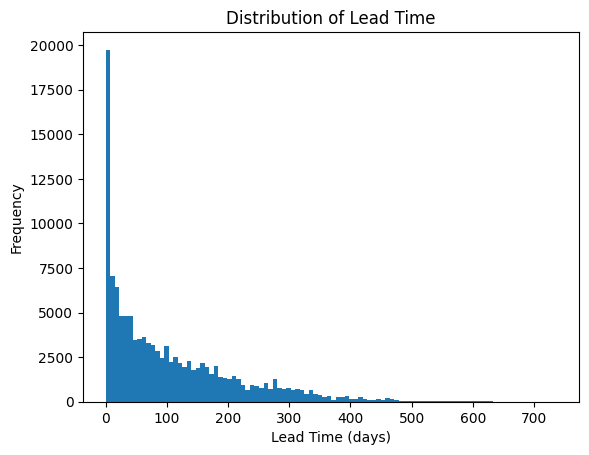

Text(0.5, 1.0, 'Distribution of ADR')

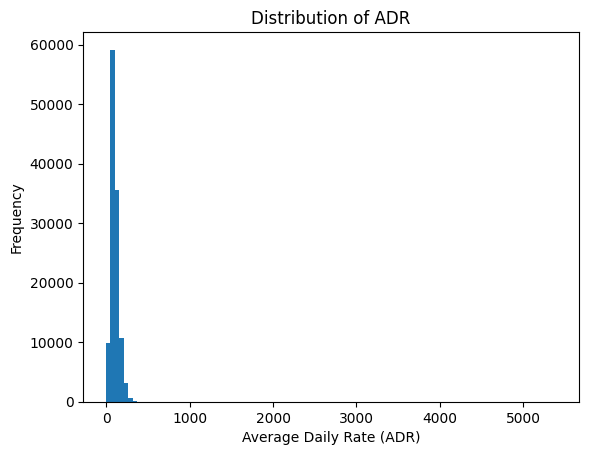

In [14]:

# Histograms
plt.figure()
plt.hist(df['lead_time'], bins=100)
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Lead Time')
plt.show()

plt.figure()
plt.hist(df['adr'], bins=100)
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Frequency')
plt.title('Distribution of ADR')

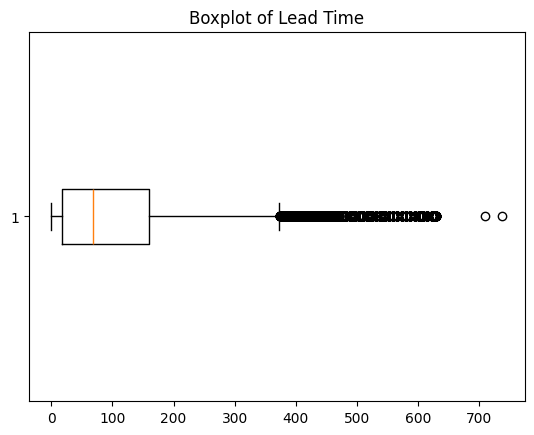

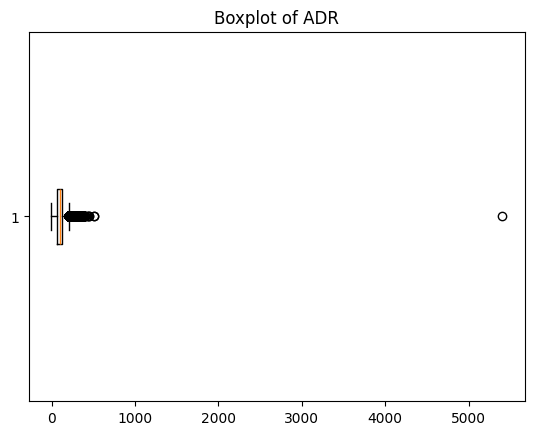

In [15]:
# Boxplots for outliers
plt.figure()
plt.boxplot(df['lead_time'], vert=False)
plt.title('Boxplot of Lead Time')
plt.show()

plt.figure()
plt.boxplot(df['adr'], vert=False)
plt.title('Boxplot of ADR')
plt.show()

Looking at the Histogram of Lead time. It is very skewed to the right, meaning most lead time are short, adr also is skewed right meaning that the adr is usually low. This suggest that bookings are usualy being completed in a very short time, and that rates are usually cheap

 The box plot confirms outliers in both variables however it is much more drastic in Lead time suggesting there are significant amounts of eally early bookings and then few luxury booking

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [19]:
# put your answer here
# Summary statistics by cancellation status
df.groupby('is_canceled')['lead_time'].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


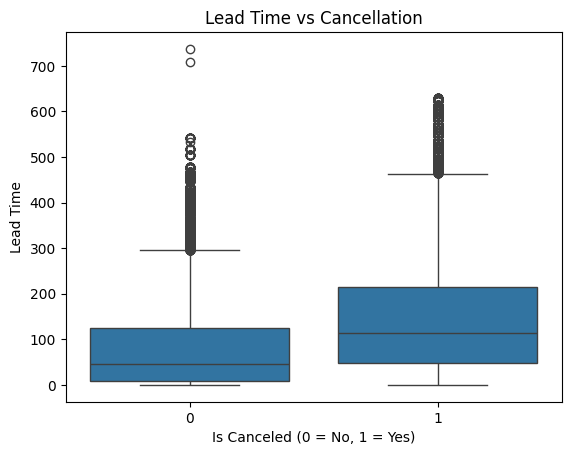

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot comparison
plt.figure()
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time')
plt.title('Lead Time vs Cancellation')
plt.show()

The mean of canceled booking is 144 lead time while non-cancceled booking is 79. The box plot confims that canceled books has very high Lead times than short bookings. This suggest that Longer Lead times can result in Canceled bookings

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [26]:
# Aggregate ADR by month and hotel type
adr_by_month_hotel = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()

# Define the correct order of months for proper sorting in plots
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
adr_by_month_hotel['arrival_date_month'] = pd.Categorical(adr_by_month_hotel['arrival_date_month'], categories=month_order, ordered=True)

# Sort the DataFrame by month for correct plotting order
adr_by_month_hotel = adr_by_month_hotel.sort_values('arrival_date_month')

print(adr_by_month_hotel)

   arrival_date_month         hotel         adr
8             January    City Hotel   82.628986
9             January  Resort Hotel   49.461883
6            February    City Hotel   85.088278
7            February  Resort Hotel   55.171930
15              March  Resort Hotel   57.520147
14              March    City Hotel   92.643116
0               April    City Hotel  111.251838
1               April  Resort Hotel   77.849496
17                May  Resort Hotel   78.758134
16                May    City Hotel  121.638560
13               June  Resort Hotel  110.444749
12               June    City Hotel  119.074341
11               July  Resort Hotel  155.181299
10               July    City Hotel  110.734292
3              August  Resort Hotel  186.790574
2              August    City Hotel  114.680455
22          September    City Hotel  110.004661
23          September  Resort Hotel   93.252030
20            October    City Hotel   99.974498
21            October  Resort Hotel   62

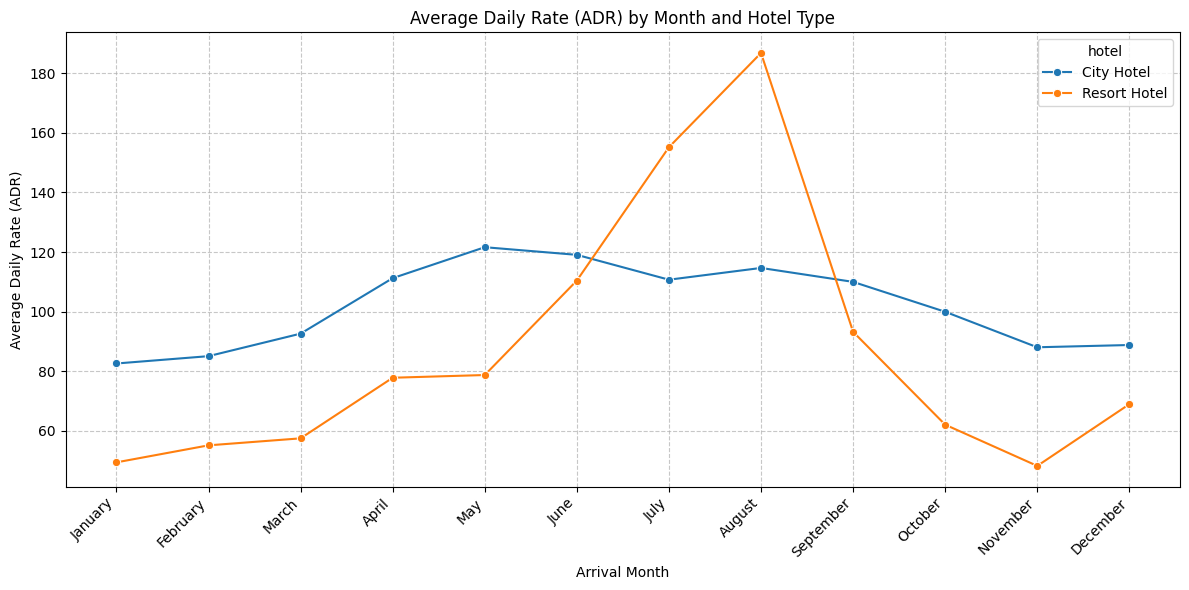

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=adr_by_month_hotel, x='arrival_date_month', y='adr', hue='hotel', marker='o')
plt.title('Average Daily Rate (ADR) by Month and Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

City Hotels and Resort Hotels exhibit distinct seasonal pricing behaviors. For City Hotels, the Average Daily Rate (ADR) tends to gradually increase from March, reaching its highest point in May (approximately 121.64), then fluctuates slightly before a secondary high in August (approximately 114.68), and then generally declines towards the end of the year.

Conversely, Resort Hotels show a different pattern. Their ADR starts lower in the winter months, begins to rise noticeably from April, and then experiences a significant surge, reaching its peak in August (approximately 186.79). After August, the ADR for Resort Hotels declines

People generally do not want swimming at winter that is why resort hotels are lower in winter

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [ ]:
# put your answer here

Cancellation Rate by Guest Type (0 = Not Repeated, 1 = Repeated):

   is_repeated_guest  is_canceled
0                  0    37.785084
1                  1    14.488189

Lead Time Statistics by Guest Type:

                      count        mean         std  min   25%   50%    75%  \
is_repeated_guest                                                             
0                  115580.0  106.425221  106.939139  0.0  21.0  72.0  163.0   
1                    3810.0   30.786352   73.411688  0.0   0.0   3.0   14.0   

                     max  
is_repeated_guest         
0                  737.0  
1                  361.0  

Booking Changes Statistics by Guest Type:

                      count      mean       std  min  25%  50%  75%   max
is_repeated_guest                                                        
0                  115580.0  0.219692  0.652030  0.0  0.0  0.0  0.0  21.0
1                    3810.0  0.264567  0.659227  0.0  0.0  0.0  0.0  10.0


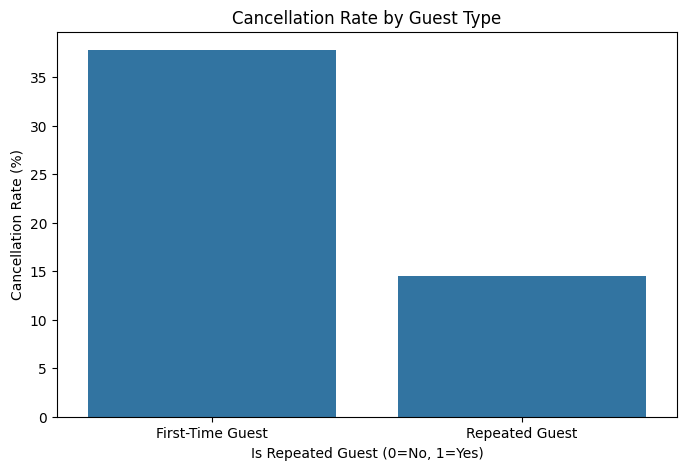

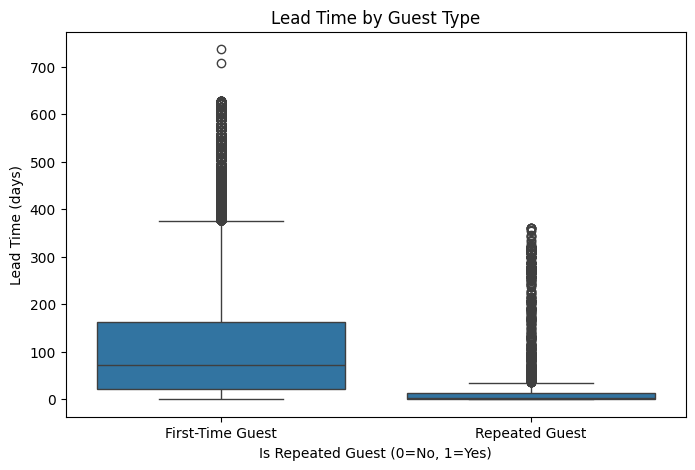

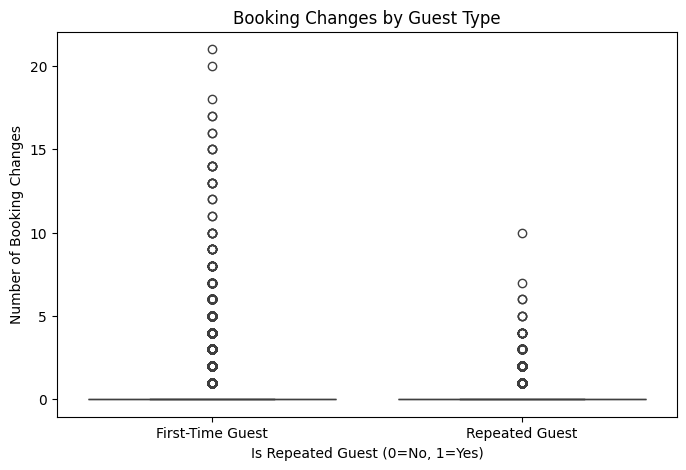

In [28]:
# Calculate cancellation rate for repeated vs. non-repeated guests
cancellation_rate_by_guest_type = df.groupby('is_repeated_guest')['is_canceled'].mean().reset_index()
cancellation_rate_by_guest_type['is_canceled'] = cancellation_rate_by_guest_type['is_canceled'] * 100 # Convert to percentage

print("Cancellation Rate by Guest Type (0 = Not Repeated, 1 = Repeated):\n")
print(cancellation_rate_by_guest_type)


# Compare lead time for repeated vs. non-repeated guests
print("\nLead Time Statistics by Guest Type:\n")
print(df.groupby('is_repeated_guest')['lead_time'].describe())

# Compare booking changes for repeated vs. non-repeated guests
print("\nBooking Changes Statistics by Guest Type:\n")
print(df.groupby('is_repeated_guest')['booking_changes'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization for Cancellation Rate
plt.figure(figsize=(8, 5))
sns.barplot(x='is_repeated_guest', y='is_canceled', data=cancellation_rate_by_guest_type)
plt.title('Cancellation Rate by Guest Type')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks([0, 1], ['First-Time Guest', 'Repeated Guest'])
plt.show()

# Visualization for Lead Time
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_repeated_guest', y='lead_time', data=df)
plt.title('Lead Time by Guest Type')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.ylabel('Lead Time (days)')
plt.xticks([0, 1], ['First-Time Guest', 'Repeated Guest'])
plt.show()

# Visualization for Booking Changes
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_repeated_guest', y='booking_changes', data=df)
plt.title('Booking Changes by Guest Type')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.ylabel('Number of Booking Changes')
plt.xticks([0, 1], ['First-Time Guest', 'Repeated Guest'])
plt.show()

Looking at the data and visualizations. It is clear that First time guest exhibits more cancellations, longer lead time, and booking changes. While repeated guest rarely do not exhibit these behaviours.

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


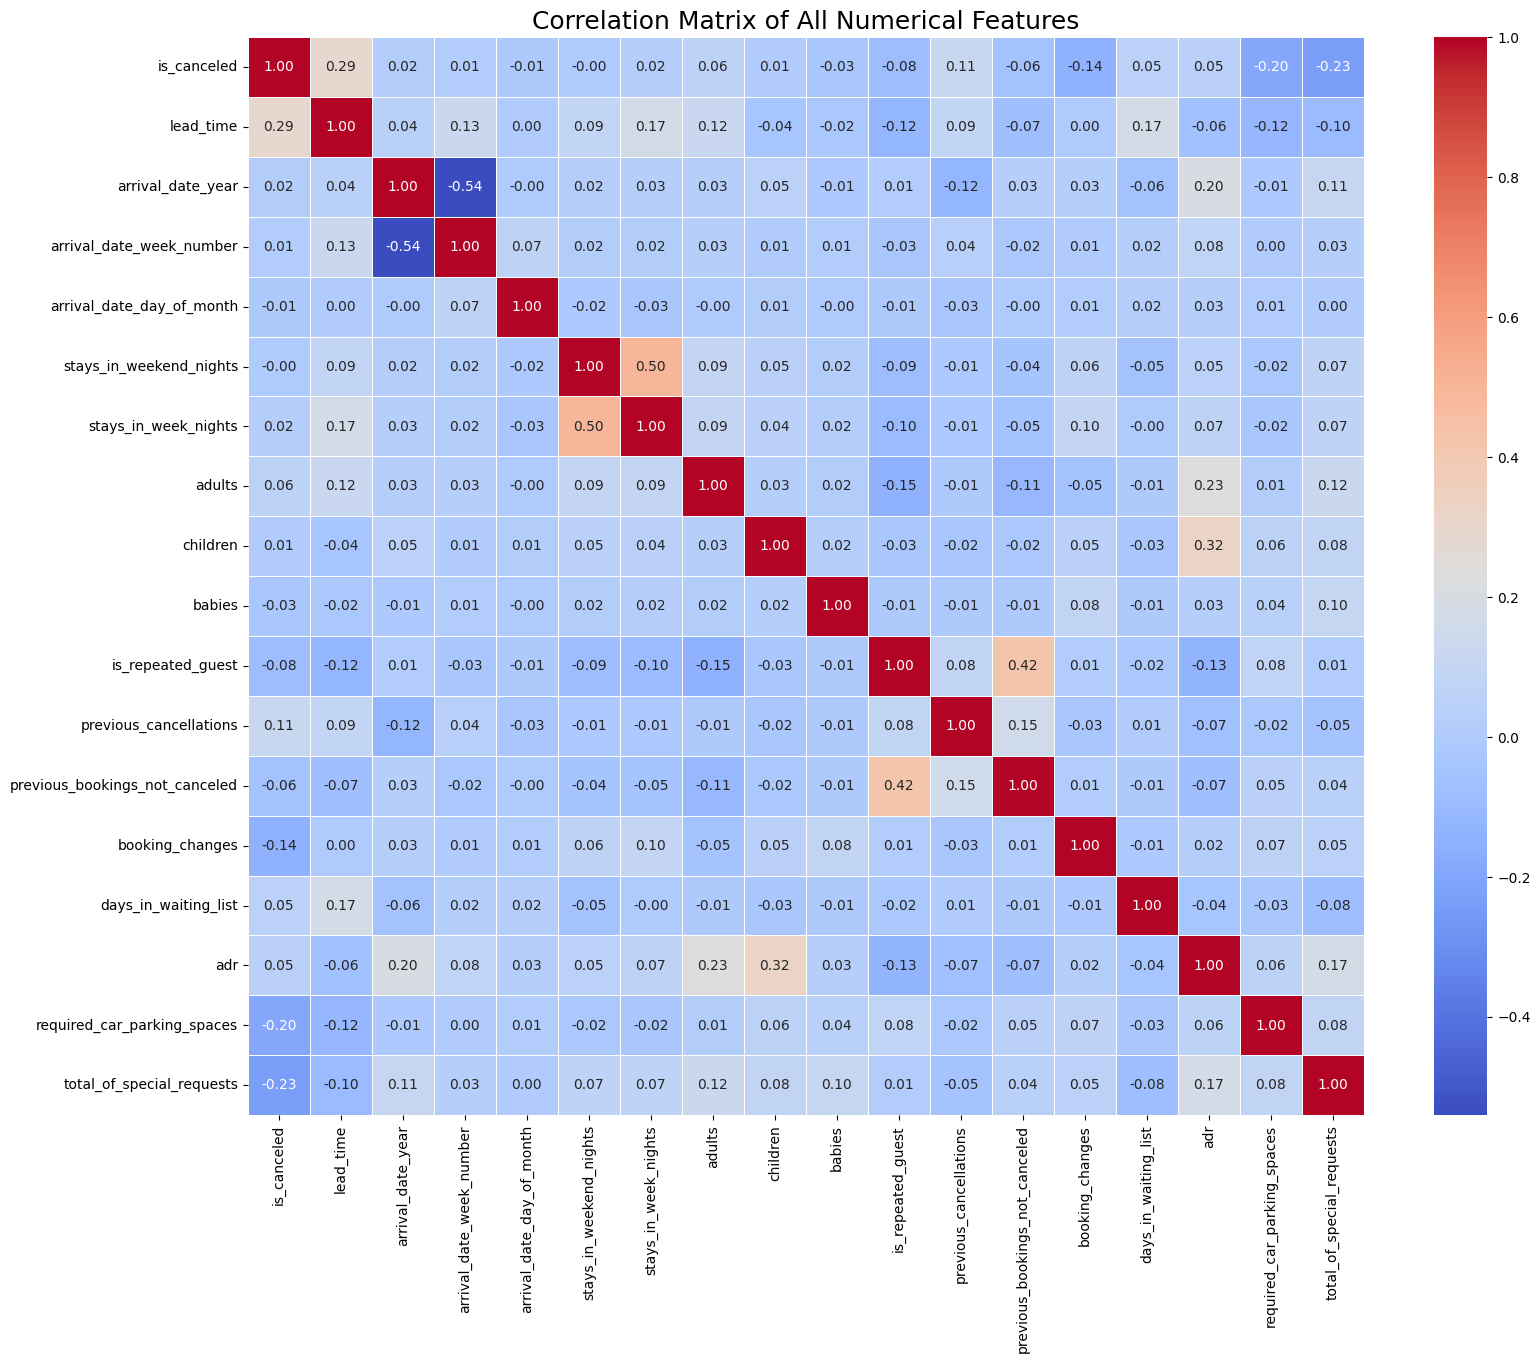

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numerical columns (excluding 'agent' and 'company' due to high NaNs, and 'hotel' and 'arrival_date_month' as they are categorical, but including 'is_canceled')
# This list includes all numerical columns from the previous analysis for consistency.
numerical_cols = [
    'is_canceled',
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# Create a new DataFrame with only the selected numerical columns
correlation_df = df[numerical_cols]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 14))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical Features', fontsize=18)
plt.show()

When looking for candidates using heatmap we check correlation per each variables. By inspecting we see that lead time, previous cancelation, and total of special request have strong correlations with cancellations

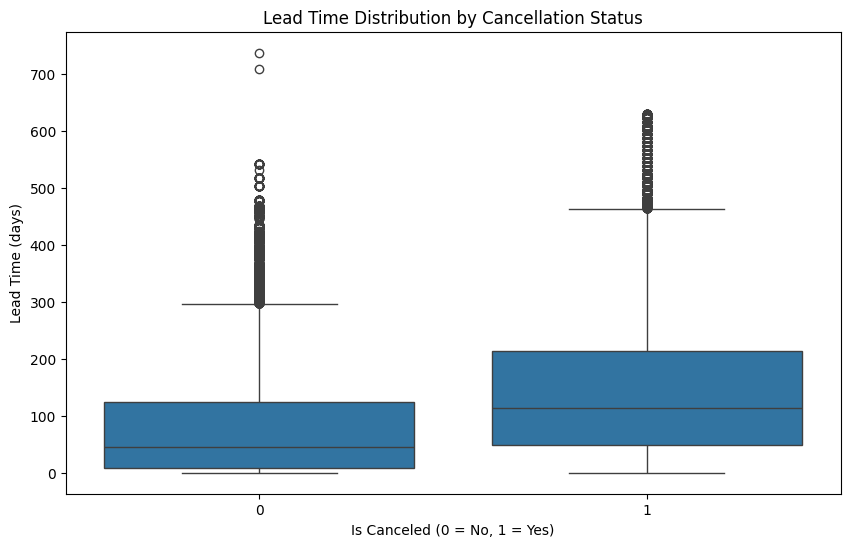

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (days)')
plt.title('Lead Time Distribution by Cancellation Status')
plt.show()

## Previous Cancellations vs. Current Cancellation Rate

### Subtask:
Calculate and visualize the cancellation rate based on the number of `previous_cancellations` to determine if guests with a history of canceling are more likely to cancel again.


**Reasoning**:
To analyze the relationship between previous cancellations and current cancellation rates, I will calculate the cancellation rate for each group of previous cancellations, convert it to a percentage, and then visualize this relationship using a bar plot as per the instructions.



Cancellation Rate by Number of Previous Cancellations:
    previous_cancellations  is_canceled  cancellation_rate
0                        0     0.339061          33.906081
1                        1     0.944307          94.430673
2                        2     0.327586          32.758621
3                        3     0.307692          30.769231
4                        4     0.225806          22.580645
5                        5     0.105263          10.526316
6                        6     0.318182          31.818182
7                       11     0.285714          28.571429
8                       13     0.916667          91.666667
9                       14     1.000000         100.000000
10                      19     1.000000         100.000000
11                      21     1.000000         100.000000
12                      24     1.000000         100.000000
13                      25     1.000000         100.000000
14                      26     1.000000         100.000000


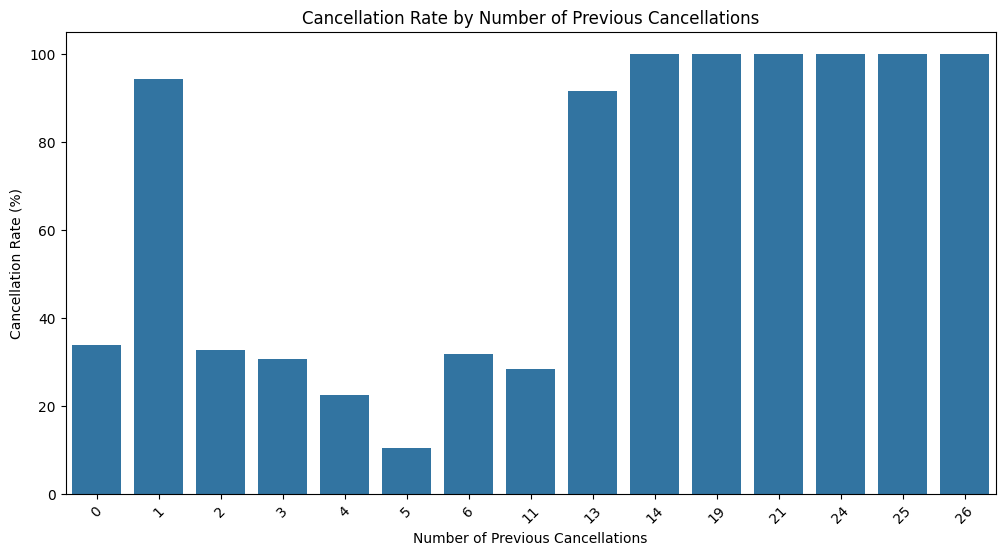

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the mean of the is_canceled column, grouped by the previous_cancellations column.
# Reset the index of the resulting DataFrame.
cancellation_rate_prev_cancellations = df.groupby('previous_cancellations')['is_canceled'].mean().reset_index()

# 2. Create a new column in this DataFrame, named 'cancellation_rate', by multiplying the 'is_canceled' column by 100 to express it as a percentage.
cancellation_rate_prev_cancellations['cancellation_rate'] = cancellation_rate_prev_cancellations['is_canceled'] * 100

# 3. Print the 'Cancellation Rate by Number of Previous Cancellations' DataFrame.
print("Cancellation Rate by Number of Previous Cancellations:")
print(cancellation_rate_prev_cancellations)

# 4. Create a bar plot using seaborn.barplot with 'previous_cancellations' on the x-axis and 'cancellation_rate' on the y-axis.
plt.figure(figsize=(12, 6))
sns.barplot(x='previous_cancellations', y='cancellation_rate', data=cancellation_rate_prev_cancellations)

# 5. Set the title of the plot to 'Cancellation Rate by Number of Previous Cancellations'.
plt.title('Cancellation Rate by Number of Previous Cancellations')

# 6. Label the x-axis 'Number of Previous Cancellations' and the y-axis 'Cancellation Rate (%).'
plt.xlabel('Number of Previous Cancellations')
plt.ylabel('Cancellation Rate (%)')

# 7. Rotate the x-axis labels by 45 degrees for better readability, if necessary.
plt.xticks(rotation=45)

# 8. Display the plot.
plt.show()

## Total of Special Requests vs. Cancellation Rate

### Subtask:
Calculate and visualize the cancellation rate based on the `total_of_special_requests`. This will help determine if guests making more special requests are more committed to their bookings.


**Reasoning**:
To analyze the relationship between the number of special requests and the cancellation rate, I will calculate the mean cancellation rate for each number of special requests, convert it to a percentage, and then visualize this relationship using a bar plot as instructed.




Cancellation Rate by Number of Special Requests:
   total_of_special_requests  is_canceled  cancellation_rate
0                          0     0.477204          47.720356
1                          1     0.220249          22.024920
2                          2     0.220989          22.098851
3                          3     0.178614          17.861434
4                          4     0.105882          10.588235
5                          5     0.050000           5.000000


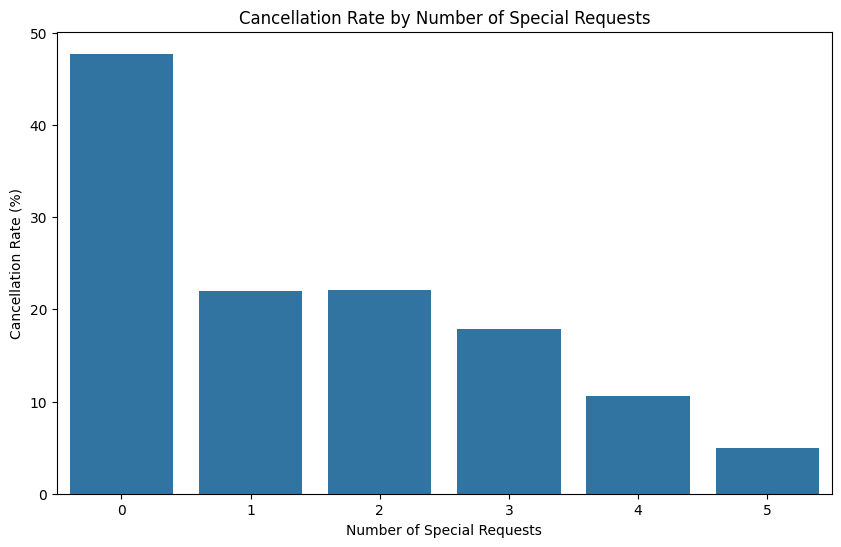

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the mean of the is_canceled column, grouped by the total_of_special_requests column.
# Reset the index of the resulting DataFrame.
cancellation_rate_special_requests = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()

# 2. Create a new column in this DataFrame, named 'cancellation_rate', by multiplying the 'is_canceled' column by 100 to express it as a percentage.
cancellation_rate_special_requests['cancellation_rate'] = cancellation_rate_special_requests['is_canceled'] * 100

# 3. Print the 'Cancellation Rate by Number of Special Requests' DataFrame.
print("\nCancellation Rate by Number of Special Requests:")
print(cancellation_rate_special_requests)

# 4. Create a bar plot using seaborn.barplot with 'total_of_special_requests' on the x-axis and 'cancellation_rate' on the y-axis.
plt.figure(figsize=(10, 6))
sns.barplot(x='total_of_special_requests', y='cancellation_rate', data=cancellation_rate_special_requests)

# 5. Set the title of the plot to 'Cancellation Rate by Number of Special Requests'.
plt.title('Cancellation Rate by Number of Special Requests')

# 6. Label the x-axis 'Number of Special Requests' and the y-axis 'Cancellation Rate (%)'.
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')

# 7. Display the plot.
plt.show()

Looking at these data. We can say while lead times increases. It leads to higher cancelations. Previous cancelation rates also makes them likely to cancel again. While number of special request by customers leads to less cancelations
